In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('spotify.csv')
df

,acousticness,billboard_artist,billboard_df_index,billboard_name,danceability,duration_ms,energy,explicit,id,instrumentalness,...,release_date,speechiness,spotify_album,spotify_artist,spotify_song,tempo,time_signature,type,uri,valence
0,0.63100,percy faith,0.0,theme from a summer place,0.466,144893.0,0.3890,0.0,2kKL5kk4On8YRSKWDgXWMX,0.843000,...,1953,0.0253,Percy Faith'S Greatest Hits,Percy Faith & His Orchestra,"The Theme From ""A Summer Place"" - Single Version",92.631,4.0,audio_features,spotify:track:2kKL5kk4On8YRSKWDgXWMX,0.749
1,0.90900,jim reeves,1.0,hell have to go,0.554,138640.0,0.1860,0.0,7DH5dXVuQaqcKf9oTy9oUN,0.001440,...,1997-02-14,0.0379,The Essential Jim Reeves,Jim Reeves,He'll Have to Go,81.181,3.0,audio_features,spotify:track:7DH5dXVuQaqcKf9oTy9oUN,0.200
2,0.41200,the everly brothers,2.0,cathys clown,0.498,144013.0,0.5820,0.0,1MA9StLzlFftLbuqOmoWij,0.000000,...,1962-06-01,0.0339,The Golden Hits Of The Everly Brothers,The Everly Brothers,Cathy's Clown,119.809,4.0,audio_features,spotify:track:1MA9StLzlFftLbuqOmoWij,0.866
3,0.85400,johnny preston,3.0,running bear,0.772,158200.0,0.2970,0.0,1RYznli2VNO7FCbW1Hq4KM,0.000008,...,2013-09-01,0.0530,Greatest Hits,Johnny Preston,Running Bear,119.987,4.0,audio_features,spotify:track:1RYznli2VNO7FCbW1Hq4KM,0.822
4,0.93600,mark dinning,4.0,teen angel,0.570,159893.0,0.0636,0.0,36NPEs4S7ik50NrlzaqoIJ,0.000000,...,2005,0.0459,Pop Megahits Of The 1950's Vol. 1,Mark Dinning,Teen Angel,101.517,4.0,audio_features,spotify:track:36NPEs4S7ik50NrlzaqoIJ,0.282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0.18400,camila cabello,5796.0,havana,0.765,217307.0,0.5230,0.0,1rfofaqEpACxVEHIZBJe6W,0.000036,...,2018-01-12,0.0300,Camila,Camila Cabello,Havana,104.988,4.0,audio_features,spotify:track:1rfofaqEpACxVEHIZBJe6W,0.394
5624,0.08050,maroon 5,5797.0,what lovers do,0.792,199849.0,0.6120,0.0,4nYsmWkuTaowTMy4gskmBw,0.000004,...,2017-11-03,0.0693,Red Pill Blues (Deluxe),Maroon 5,What Lovers Do (feat. SZA),109.959,4.0,audio_features,spotify:track:4nYsmWkuTaowTMy4gskmBw,0.420
5625,0.00419,blackbear,5798.0,do re mi,0.742,212027.0,0.5990,1.0,3Q3myFA7q4Op95DOpHplaY,0.000010,...,2017-04-21,0.0465,digital druglord,Blackbear,do re mi,110.977,3.0,audio_features,spotify:track:3Q3myFA7q4Op95DOpHplaY,0.154
5626,0.25900,xxxtentacion,5799.0,look at me,0.763,126346.0,0.7260,1.0,7floNISpH8VF4z4459Qo18,0.000000,...,2017-02-20,0.2820,Look At Me!,XXXTENTACION,Look At Me!,139.059,4.0,audio_features,spotify:track:7floNISpH8VF4z4459Qo18,0.349


In [12]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   acousticness        5628 non-null   float64
 1   billboard_artist    5628 non-null   object 
 2   billboard_df_index  5628 non-null   float64
 3   billboard_name      5628 non-null   object 
 4   danceability        5628 non-null   float64
 5   duration_ms         5628 non-null   float64
 6   energy              5628 non-null   float64
 7   explicit            5628 non-null   float64
 8   id                  5628 non-null   object 
 9   instrumentalness    5628 non-null   float64
 10  key                 5628 non-null   float64
 11  liveness            5628 non-null   float64
 12  loudness            5628 non-null   float64
 13  mode                5628 non-null   float64
 14  popularity          5628 non-null   float64
 15  release_date        5628 non-null   object 
 16  speech

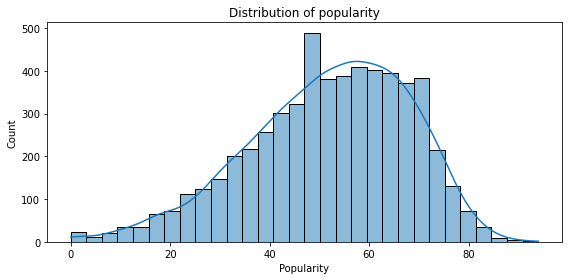

In [13]:
 # popularity hist
plt.figure(figsize=(8,4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title("Distribution of popularity")
plt.xlabel("Popularity")
plt.tight_layout()
plt.show()

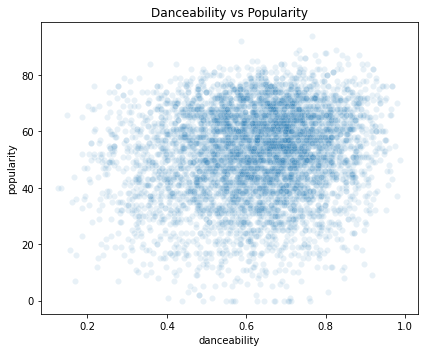

In [14]:
# Popularity and danceability?
# (no good graph too many points)
plt.figure(figsize=(6,5))
sns.scatterplot(
data=df,
x='danceability', y='popularity', alpha=0.1
)
plt.title("Danceability vs Popularity")
plt.tight_layout()
plt.show()

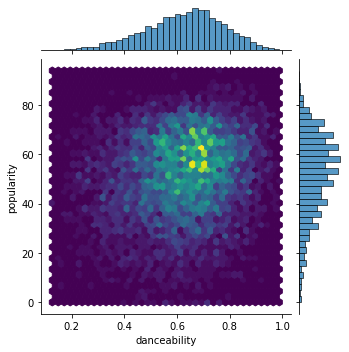

In [15]:
# Popularity and danceability (a better graph, not required)
sns.jointplot(
data=df,
x='danceability',
y='popularity',
kind='hex',
cmap='viridis',
height=5
)
plt.show()

In [16]:
# need to formally model any possible correlation
import statsmodels.api as sm
X = df[['danceability']]
X = sm.add_constant(X) # adds intercept
y = df['popularity']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     123.2
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           2.45e-28
Time:                        11:10:46   Log-Likelihood:                -23564.
No. Observations:                5628   AIC:                         4.713e+04
Df Residuals:                    5626   BIC:                         4.714e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           42.1269      0.905     46.545   

In [19]:
df.danceability.describe()

count    5628.000000
mean        0.623222
std         0.150409
min         0.126000
25%         0.527000
50%         0.636000
75%         0.728000
max         0.988000
Name: danceability, dtype: float64

In [10]:
df.popularity.mean()

51.89339019189765

Coefficient for `danceability` is positive and significant. Danceability ranges from 0-1. The interpretation of its coefficient is: a one unit increase in `danceability` is correlated with a 15.67 point increase in `popularity`. This corresponds to a (15.67/51.89)*100 = about 30% increase in popularity.

In [34]:
# Lyrics analysis

import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

df_lyrics = pd.read_csv('lyrics.csv')
df_lyrics

,artist_all,artist_base,rank,song,year,artist_featured,song_clean,artist_clean,lyrics,acousticness,...,speechiness,tempo,time_signature,valence,duration_min,num_words,words_per_sec,num_uniq_words,decade,uniq_ratio
0,percy faith,percy faith,1,theme from a summer place,1960,NaN,theme from a summer place,percy faith,theres a summer place where it may rain or sto...,0.63100,...,0.0253,92.631,4.0,0.749,2.414883,104.0,0.717771,58.0,1960,1.793103
1,jim reeves,jim reeves,2,he'll have to go,1960,NaN,hell have to go,jim reeves,put your sweet lips a little closer to the pho...,0.90900,...,0.0379,81.181,3.0,0.200,2.310667,152.0,1.096365,69.0,1960,2.202899
2,the everly brothers,the everly brothers,3,cathy's clown,1960,NaN,cathys clown,the everly brothers,dont want your love any more dont want your k...,0.41200,...,0.0339,119.809,4.0,0.866,2.400217,121.0,0.840202,64.0,1960,1.890625
3,johnny preston,johnny preston,4,running bear,1960,NaN,running bear,johnny preston,on the bank of the river stood running bear yo...,0.85400,...,0.0530,119.987,4.0,0.822,2.636667,220.0,1.390645,89.0,1960,2.471910
4,mark dinning,mark dinning,5,teen angel,1960,NaN,teen angel,mark dinning,teen angel teen angel teen angel that fateful ...,0.93600,...,0.0459,101.517,4.0,0.282,2.664883,109.0,0.681706,73.0,1960,1.493151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5561,camila cabello featuring young thug,camila cabello,96,havana,2017,young thug,havana,camila cabello,hey half of my heart is in havana ooh na na h...,0.18400,...,0.0300,104.988,4.0,0.394,3.621783,350.0,1.610625,102.0,2010,3.431373
5562,maroon 5 featuring sza,maroon 5,97,what lovers do,2017,sza,what lovers do,maroon 5,say say say hey hey now baby oh mama dont pla...,0.08050,...,0.0693,109.959,4.0,0.420,3.330817,366.0,1.831383,75.0,2010,4.880000
5563,blackbear,blackbear,98,do re mi,2017,NaN,do re mi,blackbear,do re mi fa so yeah yeah yeah oh do re mi fa ...,0.00419,...,0.0465,110.977,3.0,0.154,3.533783,382.0,1.801657,122.0,2010,3.131148
5564,xxxtentacion,xxxtentacion,99,look at me!,2017,NaN,look at me,xxxtentacion,ayy im like bitch who is your mans ayy cant k...,0.25900,...,0.2820,139.059,4.0,0.349,2.105767,337.0,2.667279,106.0,2010,3.179245


In [35]:
all_lyrics = " ".join(df_lyrics["lyrics"].astype(str))
all_lyrics[0:100]

'theres a summer place where it may rain or storm yet im safe and warm for within that summer place y'

In [49]:
tokens = word_tokenize(all_lyrics)

# get rid of stopwords like a, an, the... and punctiation like "! , ."
stop_words = set(stopwords.words('english'))

# for loop that checks if an element in the token list is a stopword or contains punctuation. If so, drops it
clean_token = []
for w in tokens:
    if w.isalpha() == True and w not in stop_words:
        clean_token.append(w)
        
freq = Counter(clean_token)

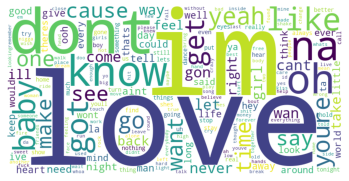

In [50]:
#! pip install wordcloud if needed
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)

plt.imshow(wc)
plt.axis('off')

plt.show()

In [51]:
freq_df = pd.DataFrame(freq.items(),columns=['word','count'])\
                            .sort_values('count',ascending=False)\
                            .reset_index(drop=True)
top_words = freq_df.head(10)
top_words

,word,count
0,love,15698
1,im,15131
2,dont,12034
3,know,11768
4,na,11229
5,oh,10941
6,like,10918
7,got,10429
8,baby,10139
9,get,8068


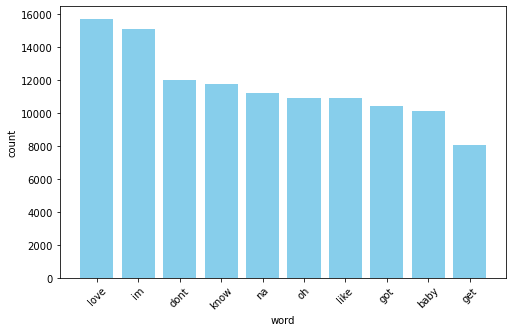

In [52]:
plt.figure(figsize=(8,5))
plt.bar(top_words['word'],top_words['count'],color='skyblue')
plt.xlabel('word')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [64]:
# positive and negative word percentages

# Read the dictionaries
with open('positive-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    poswords = f.readlines() # 2,006 words

with open('negative-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    negwords = f.readlines() # 4,783 words
    
# strip away the '\n' newline characters
pos_list=[]
for w in poswords:
    pos_list.append(w.strip())

neg_list=[]
for w in negwords:
    neg_list.append(w.strip())

# convert the dictionaries to pandas df
pos_df = pd.DataFrame(pos_list,columns=['word'])
pos_df['sentiment'] = 'positive'

neg_df = pd.DataFrame(neg_list,columns=['word'])
neg_df['sentiment'] = 'negative'


In [65]:
pos_df

,word,sentiment
0,a+,positive
1,abound,positive
2,abounds,positive
3,abundance,positive
4,abundant,positive
...,...,...
2001,youthful,positive
2002,zeal,positive
2003,zenith,positive
2004,zest,positive


In [66]:
neg_df

,word,sentiment
0,2-faced,negative
1,2-faces,negative
2,abnormal,negative
3,abolish,negative
4,abominable,negative
...,...,...
4778,zaps,negative
4779,zealot,negative
4780,zealous,negative
4781,zealously,negative


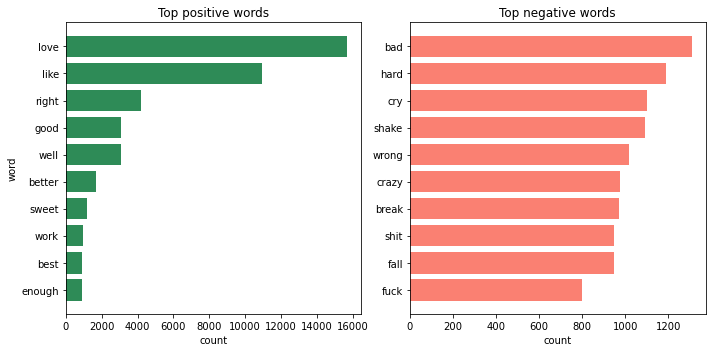

In [67]:
out_pos = pd.merge(freq_df, pos_df, on=['word'])
out_neg = pd.merge(freq_df, neg_df, on=['word'])

top_pos = out_pos.head(10)
top_neg = out_neg.head(10)

# two side by side barcharts
plt.figure(figsize=(10,5))

plt.subplot(1,2,1) # takes 3 arguments, first: number of graphs on y-axis, second: on the x axis, 
#third: which graph you are plotting
plt.barh(top_pos['word'],top_pos['count'],color='seagreen')
plt.title('Top positive words')
plt.xlabel('count')
plt.ylabel('word')
plt.gca().invert_yaxis() # inverts the y axis

plt.subplot(1,2,2)
plt.barh(top_neg['word'],top_neg['count'],color='salmon')
plt.title('Top negative words')
plt.xlabel('count')
#plt.ylabel('word')
plt.gca().invert_yaxis()


plt.tight_layout() # makes sure that axes are not touching each other
plt.show()

In [69]:
# freq of positive words that al gore used: num of positive words / number of total words
pos_freq = out_pos['count'].sum() / freq_df['count'].sum()
neg_freq = out_neg['count'].sum() / freq_df['count'].sum()

print(pos_freq)
print(neg_freq)

0.08246059363110148
0.056479566964210665


More positive words in the entire lyrics corpus!

In [91]:
# Create a function that we can call for any artist

# Read the dictionaries
with open('positive-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    poswords = f.readlines() # 2,006 words

with open('negative-words.txt', encoding='latin-1') as f: # latin-1 in case default doesn't work
    negwords = f.readlines() # 4,783 words
    
# strip away the '\n' newline characters
pos_list=[]
for w in poswords:
    pos_list.append(w.strip())

neg_list=[]
for w in negwords:
    neg_list.append(w.strip())
    
    
# this is very the function starts. It takes in artist name and returns pos and neg word ratios.
# we can use this function to loop over all artists in the data
def sentiment(artist):

    all_lyrics = " ".join(df_lyrics[df_lyrics.artist_clean==artist]["lyrics"].astype(str))

    tokens = word_tokenize(all_lyrics)

    # get rid of stopwords like a, an, the... and punctiation like "! , ."
    stop_words = set(stopwords.words('english'))

    # for loop that checks if an element in the token list is a stopword or contains punctuation. If so, drops it
    clean_token = []
    for w in tokens:
        if w.isalpha() == True and w not in stop_words:
            clean_token.append(w)

    freq = Counter(clean_token)

    freq_df = pd.DataFrame(freq.items(),columns=['word','count'])\
                                .sort_values('count',ascending=False)\
                                .reset_index(drop=True)
    


    # convert the dictionaries to pandas df
    pos_df = pd.DataFrame(pos_list,columns=['word'])
    pos_df['sentiment'] = 'positive'

    neg_df = pd.DataFrame(neg_list,columns=['word'])
    neg_df['sentiment'] = 'negative'
    
    out_pos = pd.merge(freq_df, pos_df, on=['word'])
    out_neg = pd.merge(freq_df, neg_df, on=['word'])
    
    # avoid division by zero
    total_words = freq_df['count'].sum()
    if total_words == 0:
        return {"posratio": 0, "negratio": 0}

    # freq of positive words that al gore used: num of positive words / number of total words
    pos_freq = out_pos['count'].sum() / freq_df['count'].sum()
    neg_freq = out_neg['count'].sum() / freq_df['count'].sum()
    

    return {"posratio": pos_freq, "negratio": neg_freq}

In [92]:
sentiment('percy faith') # as an example

{'posratio': 0.1702127659574468, 'negratio': 0.02127659574468085}

In [93]:
# we now loop over all artists
results = []

for artist in df_lyrics.artist_clean.unique():
    ratios = sentiment(artist)
    results.append({
        "artist": artist,
        "posratio": ratios["posratio"],
        "negratio": ratios["negratio"]
    })

result_df = pd.DataFrame(results)
result_df

,artist,posratio,negratio
0,percy faith,0.170213,0.021277
1,jim reeves,0.068493,0.095890
2,the everly brothers,0.110565,0.103194
3,johnny preston,0.124424,0.036866
4,mark dinning,0.169492,0.016949
...,...,...,...
2278,dustin lynch,0.136986,0.068493
2279,yfn lucci,0.040881,0.059748
2280,camila cabello,0.044053,0.013216
2281,blackbear,0.036364,0.036364


In [96]:
result_df.sort_values('posratio',ascending=False)

,artist,posratio,negratio
673,dennis coffey,1.000000,0.000000
1637,the blackout all stars,0.509934,0.006623
126,curtis lee,0.507692,0.000000
110,the paris sisters,0.500000,0.038462
20,frankie avalon,0.433333,0.033333
...,...,...,...
2189,silento,0.000000,0.009050
199,the surfaris,0.000000,0.000000
197,kyu sakamoto,0.000000,0.000000
1201,falco,0.000000,0.022936


In [109]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 500)
df_lyrics[df_lyrics.artist_clean=='dennis coffey'].lyrics # seems to be a data error

1240     instrumental 
Name: lyrics, dtype: object

In [110]:
df_lyrics[df_lyrics.artist_clean=='the blackout all stars'].lyrics

3741    blackout all stars miscellaneous i like it i like it like that yeah baby i like it like that i like it like that i like it like that i got soul i got soul i like it like that por ti me quiero i like it like that oh oh baby i like it like that i like it like that i like it like that si aqui me quiero mi amour i like it like that i got soul i got soul i like it like that yeah baby i like it like that i like it like that i like it like that si aqui me quiero i like it like that i want you like ...
Name: lyrics, dtype: object

In [111]:
# now for negative words
result_df.sort_values('negratio',ascending=False)

,artist,posratio,negratio
2001,metro station,0.114286,0.548571
939,the trammps,0.059211,0.289474
855,elvin bishop,0.121212,0.257576
377,b j thomas,0.012500,0.250000
1353,depeche mode,0.046875,0.250000
...,...,...,...
1170,jan hammer,0.000000,0.000000
255,al hirt,0.000000,0.000000
827,disco tex and the sex o lettes,0.000000,0.000000
251,gale garnett,0.115789,0.000000


In [112]:
df_lyrics[df_lyrics.artist_clean=='metro station'].lyrics

4698     ill take you home if you dont leave me at the front door your bodys cold but girl were getting so warm and i was thinking of ways that i could get inside this feelings tearing me up now if she does it like this will you do it like that now if she touches like this will you touch her right back now if she moves like this will you move her like that cmon shake shake shake shake a shake it shake shake shake shake a shake that shake shake shake shake a shake it shake shake shake shake a shake t...
Name: lyrics, dtype: object

In [113]:
df_lyrics[df_lyrics.artist_clean=='the trammps'].lyrics

1850     burn baby burn burn baby burn burn baby burn burn baby burn burning to my surprise listen one hundred stories high people getting loose yall getting down on the roof do you hear the funk was flaming out of control it was so entertaining when the boogie started to explode i heard somebody say burn baby burn disco inferno burn baby burn burn the mother down burn baby burn disco inferno burn baby burn burn the mother down burning satisfaction came in the chain reaction i couldnt get enough til...
Name: lyrics, dtype: object